In [86]:
# Titanic Survival Prediction
# Task 3 - Machine Learning

print("Titanic Survival Prediction Project")
print("Task 3 Started Successfully!")

Titanic Survival Prediction Project
Task 3 Started Successfully!


In [87]:
# Step 3: Import Required Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
        classification_report,
            confusion_matrix
            )

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [88]:
# Step 4: Load Titanic Dataset

df = pd.read_csv("titanic.csv")

print("Titanic dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Titanic dataset loaded successfully!
Dataset Shape: (418, 12)


In [89]:
# Step 5: View First 5 Rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [90]:
# Step 6: Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [91]:
# Step 7: Statistical Summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [92]:
# Step 8: Check Missing Values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [93]:
# Step 9: Missing Values Percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Values Percentage:")
print(missing_percentage)

Missing Values Percentage:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64


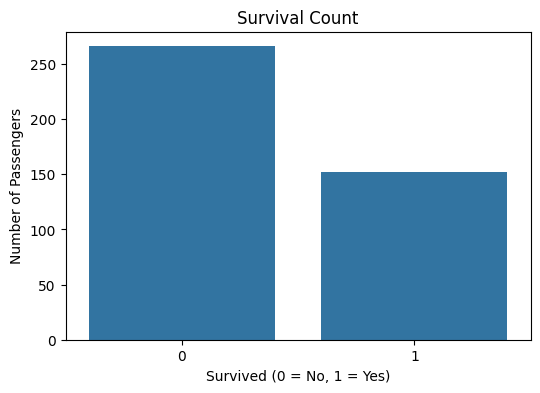

In [94]:
# Step 10: Survival Count Plot

plt.figure(figsize=(6, 4))

sns.countplot(x='Survived', data=df)

plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.show()

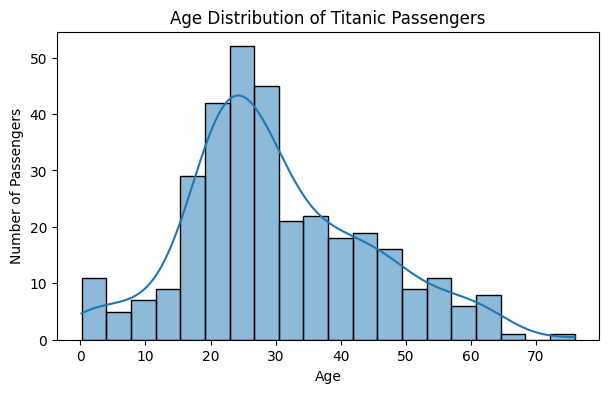

In [95]:
# Step 11: Age Distribution Histogram

plt.figure(figsize=(7, 4))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

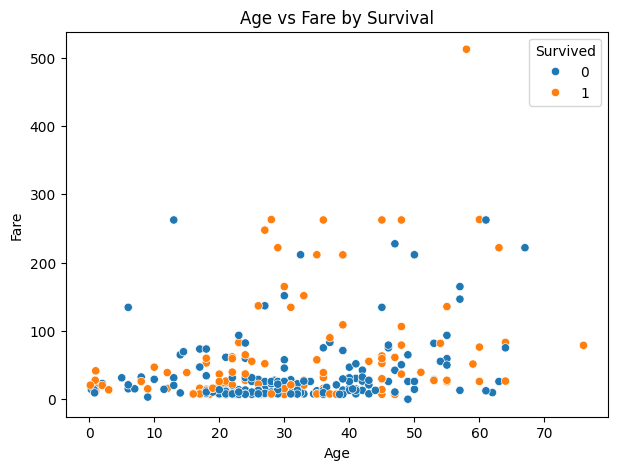

In [96]:
# Step 12: Age vs Fare Scatter Plot

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
        x='Age',
            y='Fare',
                hue='Survived'
                )
plt.title('Age vs Fare by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.show()

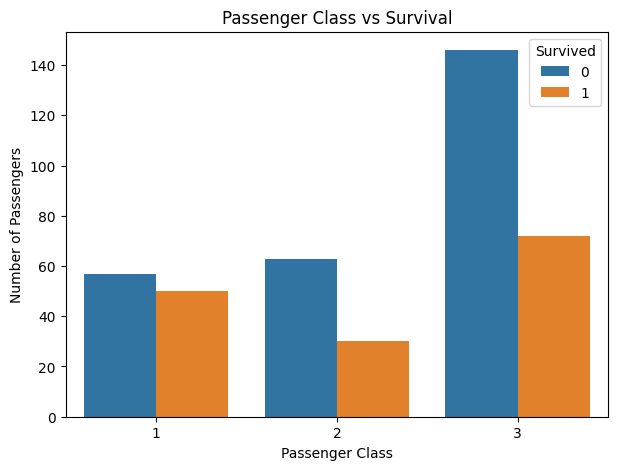

In [97]:
# Step 13: Passenger Class vs Survival

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
        x='Pclass',
            hue='Survived'
            )

plt.title('Passenger Class vs Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

In [98]:
# Step 14: Extract Title from Name

df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')

print("Title feature created successfully!")
print(df[['Name', 'Title']].head())

Title feature created successfully!
                                           Name Title
0                              Kelly, Mr. James    Mr
1              Wilkes, Mrs. James (Ellen Needs)   Mrs
2                     Myles, Mr. Thomas Francis    Mr
3                              Wirz, Mr. Albert    Mr
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)   Mrs


In [99]:
# Step 14B: Create Family Size

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("FamilySize feature created successfully!")
print(df[['SibSp', 'Parch', 'FamilySize']].head())

FamilySize feature created successfully!
   SibSp  Parch  FamilySize
0      0      0           1
1      1      0           2
2      0      0           1
3      0      0           1
4      1      1           3


In [100]:
# Step 14C: Create Cabin Presence

df['CabinPresence'] = df['Cabin'].notna().astype(int)

print("CabinPresence feature created successfully!")
print(df[['Cabin', 'CabinPresence']].head(10))

CabinPresence feature created successfully!
  Cabin  CabinPresence
0   NaN              0
1   NaN              0
2   NaN              0
3   NaN              0
4   NaN              0
5   NaN              0
6   NaN              0
7   NaN              0
8   NaN              0
9   NaN              0


In [101]:
# Step 15: Verify New Features

print("New Features Created Successfully!\n")

print(df[['Name', 'Title', 'SibSp', 'Parch', 'FamilySize',
          'Cabin', 'CabinPresence']].head(10))

New Features Created Successfully!

                                           Name Title  SibSp  Parch  \
0                              Kelly, Mr. James    Mr      0      0   
1              Wilkes, Mrs. James (Ellen Needs)   Mrs      1      0   
2                     Myles, Mr. Thomas Francis    Mr      0      0   
3                              Wirz, Mr. Albert    Mr      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)   Mrs      1      1   
5                    Svensson, Mr. Johan Cervin    Mr      0      0   
6                          Connolly, Miss. Kate  Miss      0      0   
7                  Caldwell, Mr. Albert Francis    Mr      1      1   
8     Abrahim, Mrs. Joseph (Sophie Halaut Easu)   Mrs      0      0   
9                       Davies, Mr. John Samuel    Mr      2      0   

   FamilySize Cabin  CabinPresence  
0           1   NaN              0  
1           2   NaN              0  
2           1   NaN              0  
3           1   NaN              0

In [102]:
# Step 16A: Handle Missing Values in Age and Fare

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

print("Missing values in Age and Fare handled successfully!")

print("\nRemaining missing values:")
print(df[['Age', 'Fare']].isnull().sum())

Missing values in Age and Fare handled successfully!

Remaining missing values:
Age     0
Fare    0
dtype: int64


In [103]:
# Step 16B: Remove Unnecessary Columns

df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

print("Unnecessary columns removed successfully!")

print("\nCurrent columns:")
print(df.columns.tolist())

Unnecessary columns removed successfully!

Current columns:
['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'CabinPresence']


In [104]:
# Step 17: Check Title Categories

print("Unique Titles:")
print(df['Title'].value_counts())

Unique Titles:
Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64


In [105]:
# Step 18: Group Rare Titles

common_titles = ['Mr', 'Miss', 'Mrs', 'Master']

df['Title'] = df['Title'].apply(
    lambda x: x if x in common_titles else 'Other'
    )

print("Rare titles grouped successfully!")
print("\nUpdated Title Categories:")
print(df['Title'].value_counts())

Rare titles grouped successfully!

Updated Title Categories:
Title
Mr        240
Miss       78
Mrs        72
Master     21
Other       7
Name: count, dtype: int64


In [106]:
# Step 19: One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
        columns=['Sex', 'Embarked', 'Title'],
            drop_first=True
            )

print("One-Hot Encoding completed successfully!")

print("\nNew Dataset Shape:")
print(df_encoded.shape)

print("\nFirst 5 Rows:")
df_encoded.head()

One-Hot Encoding completed successfully!

New Dataset Shape:
(418, 16)

First 5 Rows:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,CabinPresence,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Other
0,892,0,3,34.5,0,0,7.8292,1,0,True,True,False,False,True,False,False
1,893,1,3,47.0,1,0,7.0000,2,0,False,False,True,False,False,True,False
2,894,0,2,62.0,0,0,9.6875,1,0,True,True,False,False,True,False,False
3,895,0,3,27.0,0,0,8.6625,1,0,True,False,True,False,True,False,False
4,896,1,3,22.0,1,1,12.2875,3,0,False,False,True,False,False,True,False


In [107]:
# Step 20: Create Features (X) and Target (y)

X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

print("Features (X) shape:")
print(X.shape)

print("\nTarget (y) shape:")
print(y.shape)

print("\nTarget:")
print("Survived")

Features (X) shape:
(418, 15)

Target (y) shape:
(418,)

Target:
Survived


In [108]:
# Step 21: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.20,
                random_state=42,
                    stratify=y
                    )

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (334, 15)
Testing Features: (84, 15)
Training Target: (334,)
Testing Target: (84,)


In [109]:
# Step 22: Logistic Regression Baseline Model

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [110]:
# Step 23: Logistic Regression Prediction

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression predictions completed!")
print("\nFirst 10 Predictions:")
print(y_pred_logistic[:10])

Logistic Regression predictions completed!

First 10 Predictions:
[1 1 0 1 0 0 0 1 1 1]


In [111]:
# Step 24: Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred_logistic)

print("===== Logistic Regression Evaluation =====")
print("Accuracy :", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

===== Logistic Regression Evaluation =====
Accuracy : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



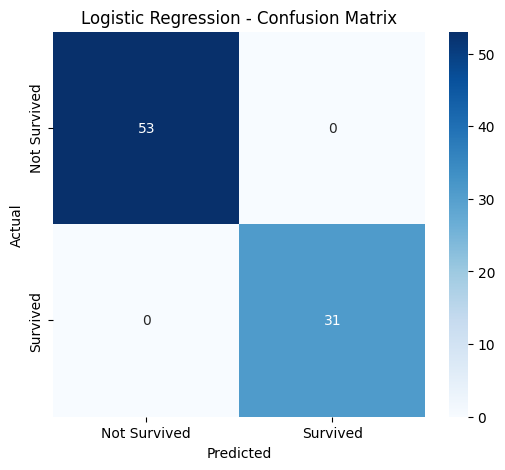

Confusion Matrix:
[[53  0]
 [ 0 31]]


In [112]:
# Step 25: Confusion Matrix

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
        annot=True,
            fmt='d',
                cmap='Blues',
                    xticklabels=['Not Survived', 'Survived'],
                        yticklabels=['Not Survived', 'Survived']
                        )

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

print("Confusion Matrix:")
print(cm)

In [113]:
# Step 26: Decision Tree Model

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
        max_depth=5
        )

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [114]:
# Step 27: Decision Tree Prediction

y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree predictions completed!")

print("\nFirst 10 Predictions:")
print(y_pred_tree[:10])

Decision Tree predictions completed!

First 10 Predictions:
[1 1 0 1 0 0 0 1 1 1]


In [115]:
# Step 28: Evaluate Decision Tree

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("===== Decision Tree Evaluation =====")
print("Accuracy :", accuracy_tree)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

===== Decision Tree Evaluation =====
Accuracy : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [116]:
# Step 29: Random Forest Model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
        random_state=42,
            max_depth=5
            )

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [117]:
# Step 30: Random Forest Prediction

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions completed!")

print("\nFirst 10 Predictions:")
print(y_pred_rf[:10])

Random Forest predictions completed!

First 10 Predictions:
[1 1 0 1 0 0 0 1 1 1]


In [118]:
# Step 31: Evaluate Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("===== Random Forest Evaluation =====")
print("Accuracy :", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

===== Random Forest Evaluation =====
Accuracy : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [119]:
# Step 32: Model Comparison

model_comparison = pd.DataFrame({
    'Model': [
            'Logistic Regression',
            'Decision Tree',
            'Random Forest'
          ],
    'Accuracy': [
            accuracy,
            accuracy_tree,
            accuracy_rf
          ]
       })

print("===== Model Comparison =====")
display(model_comparison)

===== Model Comparison =====


,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


In [120]:
# Step 33: Random Forest Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
        'Importance': random_forest_model.feature_importances_
        })

feature_importance = feature_importance.sort_values(
            by='Importance',
                ascending=False
                )
print("===== Feature Importance =====")
display(feature_importance)

===== Feature Importance =====


,Feature,Importance
8,Sex_male,0.385150
12,Title_Mr,0.275155
11,Title_Miss,0.125227
13,Title_Mrs,0.121954
2,Age,0.023792
5,Fare,0.017943
4,Parch,0.012804
6,FamilySize,0.011008
1,Pclass,0.006602
3,SibSp,0.005062


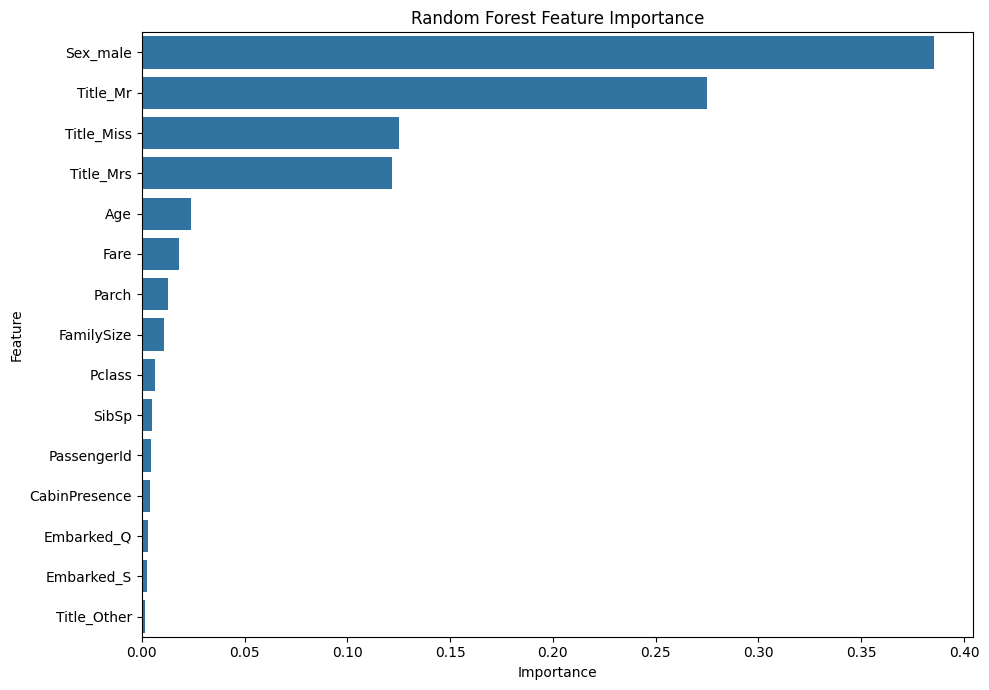

In [121]:
# Step 34: Feature Importance Visualization

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
        x='Importance',
            y='Feature'
            )
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [122]:
# Step 35: Inference Example

# Create one new passenger
new_passenger = pd.DataFrame({
    'PassengerId': [2000],
    'Pclass': [3],
    'Age': [25],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [8.05],
    'FamilySize': [1],
    'CabinPresence': [0],
    'Sex_male': [1],
    'Embarked_Q': [0],
    'Embarked_S': [1],
    'Title_Miss': [0],
    'Title_Mr': [1],
    'Title_Mrs': [0],
    'Title_Other': [0]
  })

# Make prediction
prediction = random_forest_model.predict(new_passenger)[0]

print("===== Inference Example =====")

if prediction == 1:

  print("Prediction: Survived")
else:
  print("Prediction: Not Survived")

===== Inference Example =====
Prediction: Not Survived


In [123]:
# Step 36: Save Final Model

joblib.dump(random_forest_model, 'titanic_survival_model.pkl')

print("Final model saved successfully!")

Final model saved successfully!


In [124]:
# Step 37: Load Saved Model and Test

loaded_model = joblib.load('titanic_survival_model.pkl')

test_prediction = loaded_model.predict(new_passenger)[0]

print("Saved model loaded successfully!")

if test_prediction == 1:
    print("Test Prediction: Survived")
else:
    print("Test Prediction: Not Survived")

Saved model loaded successfully!
Test Prediction: Not Survived


In [125]:
# Step 38A: Create requirements.txt

requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

    print("requirements.txt created successfully!")

requirements.txt created successfully!


In [126]:
# Step 38B: Create README.md

readme = """
# Titanic Survival Prediction

## Project Overview
This project predicts whether a Titanic passenger survived or not using Machine Learning.

## Objective
To build a classification model using passenger attributes and perform:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training
- Model evaluation
- Feature importance
- Inference using a saved model

## Dataset
Titanic dataset containing passenger information such as:
- Passenger class
- Sex
- Age
- SibSp
- Parch
- Fare
- Cabin
- Embarked

## Feature Engineering
The following features were created:
- Title
- FamilySize
- CabinPresence

## Models Used
1. Logistic Regression
2. Decision Tree
3. Random Forest

## Model Evaluation
Accuracy on the test split:

| Model | Accuracy |
|---|---:|
| Logistic Regression | 1.00 |
| Decision Tree | 1.00 |
| Random Forest | 1.00 |

## Feature Importance
Random Forest feature importance was used for model explainability.

Important features included:
- Sex_male
- Title_Mr
- Title_Miss
- Title_Mrs
- Age
- Fare

## Inference Example
A sample passenger was given to the trained Random Forest model.

Prediction:
Not Survived

## Saved Model
The trained model is saved as:

`titanic_survival_model.pkl`

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Joblib
- Google Colab

## Project Files
- `Titanic_Survival_Prediction.ipynb` — Machine Learning notebook
- `titanic_survival_model.pkl` — Saved Random Forest model
- `requirements.txt` — Required Python packages
- `README.md` — Project documentation
"""

with open("README.md", "w") as f:
    f.write(readme)

    print("README.md created successfully!")

README.md created successfully!
